In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import transforms
import matplotlib.pyplot as plt
from math import ceil, floor
from datetime import datetime 
import time
from torch.utils.data import Dataset, DataLoader
from itertools import product
from torch.utils.data.dataset import TensorDataset

torch.manual_seed(123)

# Model definition

In [13]:
device = (torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'))
print(f"Training on device {device}.")

NUM_CLASSES = 10
IMAGE_HEIGHT, IMAGE_WIDTH = 48, 60


class LocalizationCNN(nn.Module):
    def __init__(self, channels=(16, 32, 64), hidden_dim=256, dropout=0.0, num_classes=NUM_CLASSES):
        super().__init__()
        blocks = []
        in_ch = 1
        for out_ch in channels:
            blocks.extend([
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            ])
            in_ch = out_ch

        self.features = nn.Sequential(*blocks)

        with torch.no_grad():
            dummy = torch.zeros(1, 1, IMAGE_HEIGHT, IMAGE_WIDTH)
            feat_dim = self.features(dummy).reshape(1, -1).shape[1]

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes + 5),
        )

    def forward(self, x):
        return self.head(self.features(x))


model_configs = {
    'small': {'channels': (16, 32), 'hidden_dim': 128, 'dropout': 0.10},
    'base': {'channels': (16, 32, 64), 'hidden_dim': 256, 'dropout': 0.15},
    'deep': {'channels': (16, 32, 64, 96), 'hidden_dim': 256, 'dropout': 0.20},
}



Training on device cuda.


## Localization


In [14]:
def localization_loss(y_pred, y_true):
    obj_true = y_true[:, 0].float()

    detection_loss = F.binary_cross_entropy_with_logits(
        y_pred[:, 0], obj_true, reduction='none'
    )

    bbox_loss = F.mse_loss(
        torch.sigmoid(y_pred[:, 1:5]), y_true[:, 1:5].float(), reduction='none'
    ).mean(dim=1)

    class_targets = y_true[:, 5].long().clamp(min=0, max=y_pred.shape[1] - 6)
    class_loss = F.cross_entropy(y_pred[:, 5:], class_targets, reduction='none')

    total_loss = torch.where(
        obj_true > 0.5,
        detection_loss + bbox_loss + class_loss,
        detection_loss,
    )
    return total_loss.mean()



### Load data and preprocessing

In [15]:
data_path = '../data_2/'


def safe_load(path):
    if hasattr(torch.serialization, 'safe_globals'):
        with torch.serialization.safe_globals([TensorDataset]):
            return torch.load(path, map_location='cpu')
    torch.serialization.add_safe_globals([TensorDataset])
    return torch.load(path, map_location='cpu')


train_data = safe_load(f"{data_path}localization_train.pt")
val_data = safe_load(f"{data_path}localization_val.pt")
test_data = safe_load(f"{data_path}localization_test.pt")

print(len(train_data))
print(len(val_data))
print(len(test_data))

59400
6600
11000


### Normalize Images

In [16]:
def _ensure_channel_first(image):
    image = image.float()
    if image.ndim == 2:
        image = image.unsqueeze(0)
    return image


class LocalizationDataset(Dataset):
    def __init__(self, data, preprocessor=None):
        self.data = data
        self.preprocessor = preprocessor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image, target = self.data[idx]
        image = _ensure_channel_first(image)
        target = target.float()
        if self.preprocessor is not None:
            image = self.preprocessor(image)
        return image, target


train_images = torch.stack([_ensure_channel_first(x) for x, _ in train_data], dim=0)
train_mean = train_images.mean()
train_std = train_images.std().clamp_min(1e-6)
print(f"Train mean: {train_mean.item():.4f}, train std: {train_std.item():.4f}")


def preprocessor(x):
    return (x - train_mean) / train_std


batch_size = 128
train_loader = DataLoader(LocalizationDataset(train_data, preprocessor), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(LocalizationDataset(val_data, preprocessor), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(LocalizationDataset(test_data, preprocessor), batch_size=batch_size, shuffle=False)



Train mean: 0.4171, train std: 0.2138


### Hyperparameter tuning and training

In [17]:
def train_single_model(model, train_loader, val_loader, num_epochs=10, lr=1e-3, weight_decay=0.0):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc': [],
        'val_iou': [],
        'val_overall': [],
    }

    best_val_overall = float('-inf')
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0

        for images, targets in train_loader:
            images = images.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            preds = model(images)
            loss = localization_loss(preds, targets)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * images.size(0)

        train_loss = running_train_loss / len(train_loader.dataset)

        model.eval()
        running_val_loss = 0.0
        correct = 0
        total_iou = 0.0
        total_objects = 0

        with torch.no_grad():
            for images, targets in val_loader:
                images = images.to(device)
                targets = targets.to(device)
                preds = model(images)
                loss = localization_loss(preds, targets)
                running_val_loss += loss.item() * images.size(0)

                true_obj = targets[:, 0] > 0.5
                if not true_obj.any():
                    continue

                pred_obj = torch.sigmoid(preds[:, 0]) > 0.5
                pred_cls = preds[:, 5:].argmax(dim=1)
                true_cls = targets[:, 5].long()

                correct += (pred_obj & (pred_cls == true_cls) & true_obj).sum().item()

                pred_bbox = torch.sigmoid(preds[:, 1:5])[true_obj]
                true_bbox = targets[:, 1:5][true_obj]
                detected = pred_obj[true_obj]

                pred_min = pred_bbox[:, :2] - 0.5 * pred_bbox[:, 2:]
                pred_max = pred_bbox[:, :2] + 0.5 * pred_bbox[:, 2:]
                true_min = true_bbox[:, :2] - 0.5 * true_bbox[:, 2:]
                true_max = true_bbox[:, :2] + 0.5 * true_bbox[:, 2:]

                inter_min = torch.maximum(pred_min, true_min)
                inter_max = torch.minimum(pred_max, true_max)
                inter_wh = (inter_max - inter_min).clamp(min=0)
                inter_area = inter_wh[:, 0] * inter_wh[:, 1]

                pred_area = (pred_bbox[:, 2] * pred_bbox[:, 3]).clamp(min=0)
                true_area = (true_bbox[:, 2] * true_bbox[:, 3]).clamp(min=0)
                union_area = pred_area + true_area - inter_area
                iou = torch.where(union_area > 0, inter_area / union_area, torch.zeros_like(union_area))
                iou = iou * detected.float()

                total_iou += iou.sum().item()
                total_objects += true_obj.sum().item()

        val_loss = running_val_loss / len(val_loader.dataset)
        val_acc = correct / total_objects if total_objects > 0 else 0.0
        val_iou = total_iou / total_objects if total_objects > 0 else 0.0
        val_overall = 0.5 * (val_acc + val_iou)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_iou'].append(val_iou)
        history['val_overall'].append(val_overall)

        if val_overall > best_val_overall:
            best_val_overall = val_overall
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"train loss: {train_loss:.4f} | val loss: {val_loss:.4f} | "
            f"val acc: {val_acc:.4f} | val IoU: {val_iou:.4f} | val overall: {val_overall:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_overall


hyperparam_grid = {
    'model_name': ['small', 'base', 'deep'],
    'lr': [1e-3, 5e-4],
    'weight_decay': [0.0, 1e-4],
    'num_epochs': [10],
}

hyperparam_candidates = [
    {
        'model_name': model_name,
        'lr': lr,
        'weight_decay': weight_decay,
        'num_epochs': num_epochs,
    }
    for model_name, lr, weight_decay, num_epochs in product(
        hyperparam_grid['model_name'],
        hyperparam_grid['lr'],
        hyperparam_grid['weight_decay'],
        hyperparam_grid['num_epochs'],
    )
]

trained_models = {}
training_histories = {}
tuning_results = []
total_start = time.perf_counter()

for trial_idx, candidate in enumerate(hyperparam_candidates, start=1):
    trial_start = time.perf_counter()
    model_name = candidate['model_name']
    lr = candidate['lr']
    weight_decay = candidate['weight_decay']
    num_epochs = candidate['num_epochs']
    cfg = model_configs[model_name]
    trial_name = (
        f"trial_{trial_idx:02d}_{model_name}_"
        f"lr{lr:.0e}_wd{weight_decay:.0e}_e{num_epochs}"
    )

    print(
        f"\n[{trial_idx}/{len(hyperparam_candidates)}] {trial_name} | "
        f"channels={cfg['channels']} hidden={cfg['hidden_dim']} dropout={cfg['dropout']}"
    )
    current_model = LocalizationCNN(**cfg).to(device)
    current_model, history, best_val_overall = train_single_model(
        current_model,
        train_loader,
        val_loader,
        num_epochs=num_epochs,
        lr=lr,
        weight_decay=weight_decay,
    )
    trial_seconds = time.perf_counter() - trial_start

    trained_models[trial_name] = current_model
    training_histories[trial_name] = history
    tuning_results.append({
        'trial_name': trial_name,
        'model_name': model_name,
        'lr': lr,
        'weight_decay': weight_decay,
        'num_epochs': num_epochs,
        'best_val_overall': best_val_overall,
        'train_seconds': trial_seconds,
    })
    print(
        f"Best val overall for {trial_name}: {best_val_overall:.4f} | "
        f"trial time: {trial_seconds:.1f}s ({trial_seconds / 60:.2f} min)"
    )

total_seconds = time.perf_counter() - total_start
tuning_results = sorted(tuning_results, key=lambda d: d['best_val_overall'], reverse=True)

print(
    f"\nTotal tuning/training time: {total_seconds:.1f}s "
    f"({total_seconds / 60:.2f} min)"
)
print('\nHyperparameter tuning summary (sorted by best val overall):')
for result in tuning_results:
    print(
        f"{result['trial_name']:>36s} | "
        f"best val overall: {result['best_val_overall']:.4f} | "
        f"time: {result['train_seconds']:.1f}s"
    )

best_trial_name = tuning_results[0]['trial_name']
model = trained_models[best_trial_name]
print(f"\nSelected best tuning trial: {best_trial_name}")



[1/12] trial_01_small_lr1e-03_wd0e+00_e10 | channels=(16, 32) hidden=128 dropout=0.1
Epoch 01/10 | train loss: 1.9739 | val loss: 1.6735 | val acc: 0.3482 | val IoU: 0.4487 | val overall: 0.3984
Epoch 02/10 | train loss: 1.4882 | val loss: 1.3243 | val acc: 0.5153 | val IoU: 0.4752 | val overall: 0.4952
Epoch 03/10 | train loss: 1.1969 | val loss: 1.1039 | val acc: 0.6038 | val IoU: 0.4703 | val overall: 0.5371
Epoch 04/10 | train loss: 0.9812 | val loss: 1.0107 | val acc: 0.6338 | val IoU: 0.4829 | val overall: 0.5584
Epoch 05/10 | train loss: 0.8189 | val loss: 0.8726 | val acc: 0.6817 | val IoU: 0.4719 | val overall: 0.5768
Epoch 06/10 | train loss: 0.6834 | val loss: 0.7980 | val acc: 0.7157 | val IoU: 0.4643 | val overall: 0.5900
Epoch 07/10 | train loss: 0.5846 | val loss: 0.7644 | val acc: 0.7212 | val IoU: 0.4501 | val overall: 0.5856
Epoch 08/10 | train loss: 0.4939 | val loss: 0.7978 | val acc: 0.7208 | val IoU: 0.4398 | val overall: 0.5803
Epoch 09/10 | train loss: 0.4247 |

### Predictions

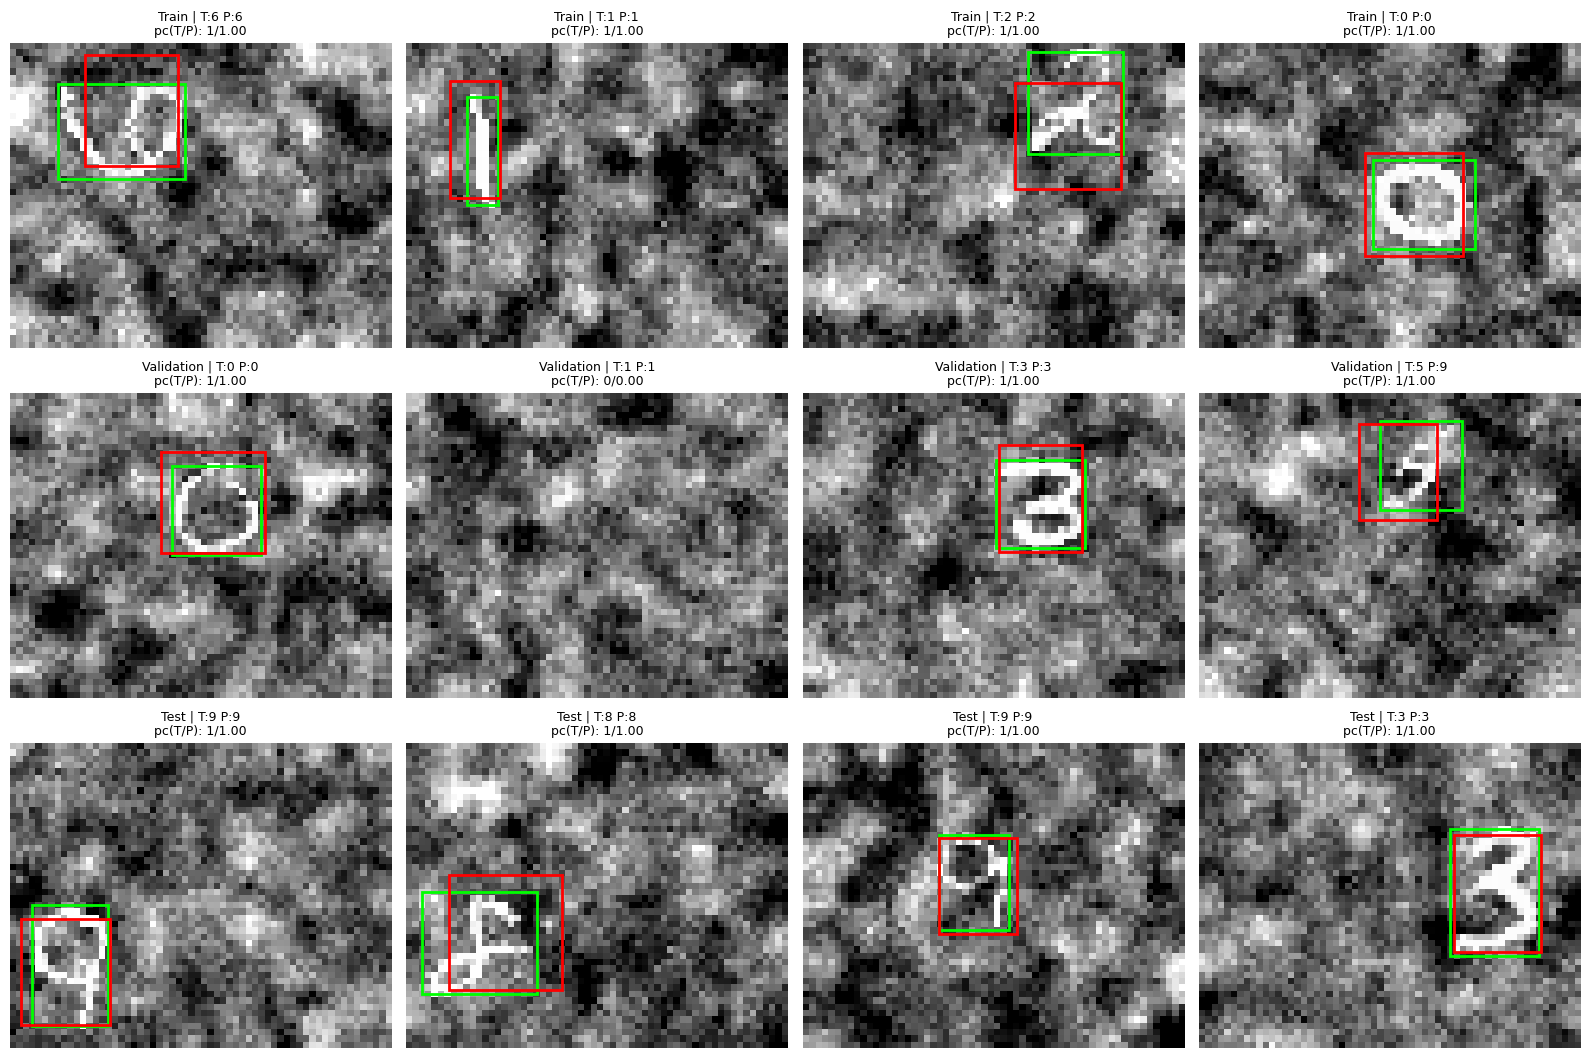

In [18]:
def _bbox_center_to_rect(bb, image_height=IMAGE_HEIGHT, image_width=IMAGE_WIDTH):
    x, y, w, h = bb.tolist()
    left = (x - 0.5 * w) * image_width
    top = (y - 0.5 * h) * image_height
    width = w * image_width
    height = h * image_height
    return left, top, width, height


plot_model = globals().get('best_model')
if plot_model is None:
    plot_model = globals().get('model')
if plot_model is None:
    raise RuntimeError('No trained model found. Run the training/model-selection cells first.')

plot_model.eval()

splits = [
    ('Train', train_data),
    ('Validation', val_data),
    ('Test', test_data),
]

samples_per_split = 4
fig, axes = plt.subplots(len(splits), samples_per_split, figsize=(4 * samples_per_split, 3.6 * len(splits)))

if len(splits) == 1:
    axes = [axes]

with torch.no_grad():
    for row, (split_name, dataset) in enumerate(splits):
        indices = torch.randperm(len(dataset))[:samples_per_split]
        for col, idx in enumerate(indices):
            ax = axes[row][col]
            image, target = dataset[int(idx)]
            image = _ensure_channel_first(image)

            model_input = preprocessor(image).unsqueeze(0).to(device)
            pred = plot_model(model_input).cpu().squeeze(0)

            pred_pc = torch.sigmoid(pred[0]).item()
            pred_label = pred[5:].argmax().item()
            pred_bbox = torch.sigmoid(pred[1:5])

            true_pc = int(target[0].item())
            true_label = int(target[5].item())
            true_bbox = target[1:5]

            ax.imshow(image.squeeze(0), cmap='gray')

            if true_pc == 1:
                l, t, w, h = _bbox_center_to_rect(true_bbox)
                ax.add_patch(plt.Rectangle((l, t), w, h, fill=False, edgecolor='lime', linewidth=2))

            if pred_pc > 0.5:
                l, t, w, h = _bbox_center_to_rect(pred_bbox)
                ax.add_patch(plt.Rectangle((l, t), w, h, fill=False, edgecolor='red', linewidth=2))

            ax.set_title(
                f"{split_name} | T:{true_label} P:{pred_label}\npc(T/P): {true_pc}/{pred_pc:.2f}",
                fontsize=9,
            )
            ax.axis('off')

plt.tight_layout()
plt.show()



### Model selection and evaluation

In [19]:
def intersection(bb1, bb2):
    """
    Compute intersection between 2 bb, in global frame of ref
    bb format: [x_center, y_center, width, height]
    """
    bb1 = torch.as_tensor(bb1, dtype=torch.float32)
    bb2 = torch.as_tensor(bb2, dtype=torch.float32)

    bb1_min = bb1[:2] - 0.5 * bb1[2:]
    bb1_max = bb1[:2] + 0.5 * bb1[2:]
    bb2_min = bb2[:2] - 0.5 * bb2[2:]
    bb2_max = bb2[:2] + 0.5 * bb2[2:]

    inter_min = torch.maximum(bb1_min, bb2_min)
    inter_max = torch.minimum(bb1_max, bb2_max)
    inter_wh = (inter_max - inter_min).clamp(min=0)
    return (inter_wh[0] * inter_wh[1]).item()


def IoU(bb1, bb2):
    """
    Compute IoU given 2 bb (local or global)
    """
    bb1 = torch.as_tensor(bb1, dtype=torch.float32)
    bb2 = torch.as_tensor(bb2, dtype=torch.float32)

    inter = intersection(bb1, bb2)
    area1 = (bb1[2] * bb1[3]).item()
    area2 = (bb2[2] * bb2[3]).item()
    union = area1 + area2 - inter
    if union <= 0:
        return 0.0
    return inter / union


def compute_IoU_localization(model, loader, preprocessor):
    """
    Compute IoU performance of the model on the given dataset
    """
    model.eval()
    total_iou = 0.0
    total_objects = 0

    with torch.no_grad():
        for images, targets in loader:
            if preprocessor is not None:
                images = preprocessor(images)

            images = images.to(device)
            targets = targets.to(device)
            preds = model(images)

            true_obj = targets[:, 0] > 0.5
            if not true_obj.any():
                continue

            pred_obj = torch.sigmoid(preds[:, 0]) > 0.5
            pred_bbox = torch.sigmoid(preds[:, 1:5])
            true_bbox = targets[:, 1:5]

            pred_bbox = pred_bbox[true_obj]
            true_bbox = true_bbox[true_obj]
            detected = pred_obj[true_obj]

            pred_min = pred_bbox[:, :2] - 0.5 * pred_bbox[:, 2:]
            pred_max = pred_bbox[:, :2] + 0.5 * pred_bbox[:, 2:]
            true_min = true_bbox[:, :2] - 0.5 * true_bbox[:, 2:]
            true_max = true_bbox[:, :2] + 0.5 * true_bbox[:, 2:]

            inter_min = torch.maximum(pred_min, true_min)
            inter_max = torch.minimum(pred_max, true_max)
            inter_wh = (inter_max - inter_min).clamp(min=0)
            inter_area = inter_wh[:, 0] * inter_wh[:, 1]

            pred_area = (pred_bbox[:, 2] * pred_bbox[:, 3]).clamp(min=0)
            true_area = (true_bbox[:, 2] * true_bbox[:, 3]).clamp(min=0)
            union_area = pred_area + true_area - inter_area

            iou = torch.where(union_area > 0, inter_area / union_area, torch.zeros_like(union_area))
            iou = iou * detected.float()

            total_iou += iou.sum().item()
            total_objects += true_obj.sum().item()

    if total_objects == 0:
        return 0.0
    return total_iou / total_objects


def compute_accuracy_localization(model, loader, preprocessor):
    """
    Compute accuracy of the model on the given dataset
    """
    model.eval()
    total_objects = 0
    correct = 0

    with torch.no_grad():
        for images, targets in loader:
            if preprocessor is not None:
                images = preprocessor(images)

            images = images.to(device)
            targets = targets.to(device)
            preds = model(images)

            true_obj = targets[:, 0] > 0.5
            if not true_obj.any():
                continue

            pred_obj = torch.sigmoid(preds[:, 0]) > 0.5
            pred_cls = preds[:, 5:].argmax(dim=1)
            true_cls = targets[:, 5].long()

            batch_correct = pred_obj & (pred_cls == true_cls) & true_obj
            correct += batch_correct.sum().item()
            total_objects += true_obj.sum().item()

    if total_objects == 0:
        return 0.0
    return correct / total_objects


# Model selection based on validation overall performance
if 'trained_models' not in globals() or len(trained_models) == 0:
    trained_models = {'single_model': model}

validation_results = {}
for model_name, current_model in trained_models.items():
    val_acc = compute_accuracy_localization(current_model, val_loader, preprocessor=None)
    val_iou = compute_IoU_localization(current_model, val_loader, preprocessor=None)
    val_overall = 0.5 * (val_acc + val_iou)
    validation_results[model_name] = {
        'accuracy': val_acc,
        'iou': val_iou,
        'overall': val_overall,
    }

print('Validation results per model:')
for model_name, metrics in validation_results.items():
    print(
        f"{model_name:>8s} | "
        f"accuracy: {metrics['accuracy']:.4f} | "
        f"IoU: {metrics['iou']:.4f} | "
        f"overall: {metrics['overall']:.4f}"
    )

best_model_name = max(validation_results, key=lambda n: validation_results[n]['overall'])
best_model = trained_models[best_model_name]
model = best_model  # keep a common reference for downstream cells

print(f"\nSelected best model: {best_model_name}")

# Evaluate the best model on test data
test_acc = compute_accuracy_localization(best_model, test_loader, preprocessor=None)
test_iou = compute_IoU_localization(best_model, test_loader, preprocessor=None)
test_overall = 0.5 * (test_acc + test_iou)

print(f"Test accuracy: {test_acc:.4f}")
print(f"Test IoU:      {test_iou:.4f}")
print(f"Test overall:  {test_overall:.4f}")



Validation results per model:
trial_01_small_lr1e-03_wd0e+00_e10 | accuracy: 0.7287 | IoU: 0.4578 | overall: 0.5932
trial_02_small_lr1e-03_wd1e-04_e10 | accuracy: 0.7320 | IoU: 0.4634 | overall: 0.5977
trial_03_small_lr5e-04_wd0e+00_e10 | accuracy: 0.6540 | IoU: 0.4566 | overall: 0.5553
trial_04_small_lr5e-04_wd1e-04_e10 | accuracy: 0.6777 | IoU: 0.4847 | overall: 0.5812
trial_05_base_lr1e-03_wd0e+00_e10 | accuracy: 0.8873 | IoU: 0.5391 | overall: 0.7132
trial_06_base_lr1e-03_wd1e-04_e10 | accuracy: 0.8903 | IoU: 0.5809 | overall: 0.7356
trial_07_base_lr5e-04_wd0e+00_e10 | accuracy: 0.8798 | IoU: 0.5643 | overall: 0.7221
trial_08_base_lr5e-04_wd1e-04_e10 | accuracy: 0.8740 | IoU: 0.5887 | overall: 0.7313
trial_09_deep_lr1e-03_wd0e+00_e10 | accuracy: 0.9272 | IoU: 0.5727 | overall: 0.7499
trial_10_deep_lr1e-03_wd1e-04_e10 | accuracy: 0.9295 | IoU: 0.5953 | overall: 0.7624
trial_11_deep_lr5e-04_wd0e+00_e10 | accuracy: 0.9123 | IoU: 0.5823 | overall: 0.7473
trial_12_deep_lr5e-04_wd1e-04_e

### Loss comparison across trained models

In [1]:
def compute_average_localization_loss(model, loader, preprocessor=None):
    model.eval()
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for images, targets in loader:
            if preprocessor is not None:
                images = preprocessor(images)

            images = images.to(device)
            targets = targets.to(device)
            preds = model(images)

            batch_size = images.size(0)
            total_loss += localization_loss(preds, targets).item() * batch_size
            total_samples += batch_size

    if total_samples == 0:
        return float('nan')
    return total_loss / total_samples


if 'training_histories' not in globals() or len(training_histories) == 0:
    raise RuntimeError('No training histories found. Run the hyperparameter tuning and training cell first.')
if 'trained_models' not in globals() or len(trained_models) == 0:
    raise RuntimeError('No trained models found. Run the hyperparameter tuning and training cell first.')

loss_histories = {
    model_name: {
        'train_loss': list(history.get('train_loss', [])),
        'val_loss': list(history.get('val_loss', [])),
    }
    for model_name, history in training_histories.items()
}

loss_summary = []
for model_name, history in loss_histories.items():
    train_losses = history['train_loss']
    val_losses = history['val_loss']
    if len(train_losses) == 0 or len(val_losses) == 0:
        continue

    best_train_loss = min(train_losses)
    best_val_loss = min(val_losses)
    best_val_epoch = val_losses.index(best_val_loss) + 1
    loss_summary.append({
        'model_name': model_name,
        'best_train_loss': best_train_loss,
        'best_val_loss': best_val_loss,
        'best_val_epoch': best_val_epoch,
    })

if len(loss_summary) == 0:
    raise RuntimeError('Training histories do not contain train/validation losses.')

loss_summary = sorted(loss_summary, key=lambda item: (item['best_val_loss'], item['model_name']))
lowest_val_loss = loss_summary[0]['best_val_loss']
loss_tolerance = 1e-12
best_validation_loss_models = [
    item['model_name']
    for item in loss_summary
    if abs(item['best_val_loss'] - lowest_val_loss) <= loss_tolerance
]

print('Best training and validation loss per model:')
for item in loss_summary:
    marker = ' <-- lowest validation loss' if item['model_name'] in best_validation_loss_models else ''
    print(
        f"{item['model_name']:>36s} | "
        f"best train loss: {item['best_train_loss']:.4f} | "
        f"best val loss: {item['best_val_loss']:.4f} "
        f"(epoch {item['best_val_epoch']}){marker}"
    )

model_names = [item['model_name'] for item in loss_summary]
best_train_losses = [item['best_train_loss'] for item in loss_summary]
best_val_losses = [item['best_val_loss'] for item in loss_summary]
y_positions = list(range(len(model_names)))
bar_height = 0.38

fig, ax = plt.subplots(figsize=(12, max(5, 0.55 * len(model_names))))
ax.barh(
    [y - bar_height / 2 for y in y_positions],
    best_train_losses,
    height=bar_height,
    label='Best train loss',
    color='#4C78A8',
)
ax.barh(
    [y + bar_height / 2 for y in y_positions],
    best_val_losses,
    height=bar_height,
    label='Best validation loss',
    color='#F58518',
)
ax.set_yticks(y_positions)
ax.set_yticklabels(model_names)
ax.invert_yaxis()
ax.set_xlabel('Loss')
ax.set_title('Best training and validation loss by trained model')
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.3)

for idx, model_name in enumerate(model_names):
    if model_name in best_validation_loss_models:
        ax.text(
            best_val_losses[idx],
            idx + bar_height / 2,
            ' lowest val',
            va='center',
            ha='left',
            fontsize=9,
            color='#C44E52',
        )

plt.tight_layout()
plt.show()

final_test_losses = {}
for model_name in best_validation_loss_models:
    if model_name not in trained_models:
        raise KeyError(f'Model {model_name} is missing from trained_models.')
    final_test_losses[model_name] = compute_average_localization_loss(
        trained_models[model_name],
        test_loader,
        preprocessor=None,
    )

print('\nBest-performing model(s) based on the lowest validation loss:')
for model_name in best_validation_loss_models:
    matching_summary = next(item for item in loss_summary if item['model_name'] == model_name)
    print(
        f"{model_name:>36s} | "
        f"best val loss: {matching_summary['best_val_loss']:.4f} | "
        f"final test loss: {final_test_losses[model_name]:.4f}"
    )

test_model_names = list(final_test_losses.keys())
test_losses = [final_test_losses[name] for name in test_model_names]

fig, ax = plt.subplots(figsize=(10, max(3.5, 0.8 * len(test_model_names))))
bars = ax.barh(test_model_names, test_losses, color='#54A24B')
ax.invert_yaxis()
ax.set_xlabel('Loss')
ax.set_title('Final test loss for the lowest validation-loss model(s)')
ax.grid(axis='x', linestyle='--', alpha=0.3)

for bar, loss in zip(bars, test_losses):
    ax.text(loss, bar.get_y() + bar.get_height() / 2, f' {loss:.4f}', va='center', ha='left')

plt.tight_layout()
plt.show()


RuntimeError: No training histories found. Run the hyperparameter tuning and training cell first.